# CS 6330 Data Science Project

**Project Title**: Global Aviation Infrastructure Analysis

*   Name: Voleak Lim
*   CID: 81488194
*   Contact: vlim2@angelo.edu
*   GitHub: https://github.com/limvoleak1128/CS-6330-aviation-project

*   Project idea: This project examines how physical infrastructure shapes global air connectivity. Specifically, it investigates whether airport elevation, geographic position, and airport size influence the distance and type of routes an airport can support. Rather than treating aviation purely as
an economic or demand-driven network, this analysis approaches it from
an infrastructure perspective — asking whether the physical characteristics
of an airport constrain or define its role in the global flight network. By integrating airline, airport, and route data, the project applies
regression, classification, and clustering methods to uncover patterns
that predefined labels and conventional assumptions do not fully capture.

# Dataset

- URL: https://www.kaggle.com/datasets/darkmatternet/global-flights-airports-airlines/data?select=airlines.csv
- Description:This dataset integrates three primary aviation files: Airports, Airlines, and Routes. By combining crowdsourced airport and airline data with commercial route information, the dataset provides a comprehensive view of global connectivity, including small regional airfields and inactive carriers.
- Columns and key features:
  1. Airports Table (85,116 rows × 19 columns): elevation_ft, type, continent iso_country, and iata_code
  2. Airlines Table (1,536 rows × 8 columns): callsign, airline_name, and iata_code
  3. Routes Table (66,379 rows × 19 columns): distance_km, airline_name, src_iata, dst_iata, airline_iata, src_country, and dst_country
- Merged Identifiers:  IATA codes used by airlines and airports, including IATA 2-letter and 3-letter codes.

## Project Goals
This project investigates global aviation through five analytical goals:

1. Data Integration: Successfully merge the airlines, airports, and routes
   datasets into a single unified master dataset for analysis.

2. Infrastructure Analysis: Investigate whether source airport elevation
   significantly influences route distance, using latitude and longitude
   as geographic supporting features.

3. Route Type Analysis: Classify routes as domestic or international based on
   geographic and infrastructure features.

4. Traffic Dominance Analysis: Identify the top countries by total inbound
   and outbound flight volume, detect countries where a single airline controls
   more than 70% of routes, and map the most intense continent-to-continent
   traffic corridors.

5. Capacity Analysis: Examine whether medium-sized airports exist that handle
   a disproportionately high number of routes relative to large airports,
   challenging the assumption that airport size determines route capacity.

6. Missing Value Study: Investigate whether empty callsign entries represent
   unrecorded data or airlines that genuinely operate without a callsign.
   **Note**: This goal was set aside during the discovery phase after revealing
   395 missing values, making manual verification impractical. The missing
   values are handled with an 'Unknown' placeholder instead.

This notebook covers the supervised and unsupervised learning section of
the project. The necessary libraries are loaded below, along with the
cleaned and merged master dataset produced in exploration.ipynb.

In [4]:
# ── Standard libraries ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Models ──────────────────────────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans

# ── Scikit-learn: Preprocessing & Model Selection ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, silhouette_score,
    classification_report, confusion_matrix
)

In [5]:
# ── Mount Google Drive to access dataset files stored in Drive ────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── Define file path and load the the merge dataset into dataframes ─────
path = '/content/drive/My Drive/CS-6330-aviation-project/dataset/final_cleaned_flight_data.csv'

master_df = pd.read_csv(path)     # cleaned and merged dataset produced in exploration.ipynb

# 4. Supervised Learning

For the supervised learning component, we apply a Support Vector Machine (SVM)
to classify flight routes as either domestic or international. SVM is chosen
because it is well-suited for binary classification tasks where the goal is to
find a clear decision boundary between two classes. Unlike KNN, which becomes
computationally expensive on large datasets, and Naive Bayes, which assumes
feature independence, SVM handles correlated and mixed features more effectively, making it a better fit for this dataset.

## 4.1 Support Vector Machine (SVM)

In this section, we apply a Support Vector Machine (SVM) to classify flight routes
as domestic or international. SVM works by finding the optimal hyperplane that best
separates the two classes in the feature space. We use distance_km, geographic
coordinates, elevation, stops, airport type, and continent as features, since these
are the most relevant variables for distinguishing domestic from international routes.

In [7]:
# ── Create target variable ────────────────────────────────────────────────
master_df_svm = master_df.dropna(subset=['src_country', 'dst_country']).copy()
master_df_svm['is_domestic'] = (
    master_df_svm['src_country'] == master_df_svm['dst_country']
).astype(int)

# ── Select features ───────────────────────────────────────────────────────
features = ['distance_km', 'src_lat', 'src_lon', 'dst_lat', 'dst_lon',
            'src_elevation', 'dst_elevation', 'stops',
            'src_airport_type', 'dst_airport_type',
            'src_continent', 'dst_continent']

X = master_df_svm[features].copy()
y = master_df_svm['is_domestic']

# ── Encode categorical features ───────────────────────────────────────────
le = LabelEncoder()
for col in ['src_airport_type', 'dst_airport_type', 'src_continent', 'dst_continent']:
    X[col] = le.fit_transform(X[col])

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows")
print(f"Testing set size  : {X_test.shape[0]} rows")
print(f"\nClass distribution in target:")
print(y.value_counts().rename({0: 'International', 1: 'Domestic'}))

Training set size : 53061 rows
Testing set size  : 13266 rows

Class distribution in target:
is_domestic
International    33747
Domestic         32580
Name: count, dtype: int64


In [8]:
# ── Train SVM model ───────────────────────────────────────────────────────
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test)

# ── Evaluation ────────────────────────────────────────────────────────────
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['International', 'Domestic']))

Accuracy: 0.7450

Classification Report:
               precision    recall  f1-score   support

International       0.77      0.72      0.74      6801
     Domestic       0.72      0.77      0.75      6465

     accuracy                           0.74     13266
    macro avg       0.75      0.75      0.74     13266
 weighted avg       0.75      0.74      0.74     13266



**Interpretation of Results**

The SVM model achieves an overall accuracy of 74%, correctly classifying 3 out
of 4 routes. Both classes perform consistently, with precision and recall scores sitting around 0.72–0.76 for both international and domestic routes, indicating that the model does not significantly favour one class over the other. The macro average F1-score of 0.74 further confirms this balance.

These results suggest that the geographic and infrastructure features used — such as distance, coordinates, airport type, and continent — carry meaningful signal for distinguishing domestic from international routes, though the remaining 26% misclassification rate indicates that some routes share overlapping characteristics regardless of their type.

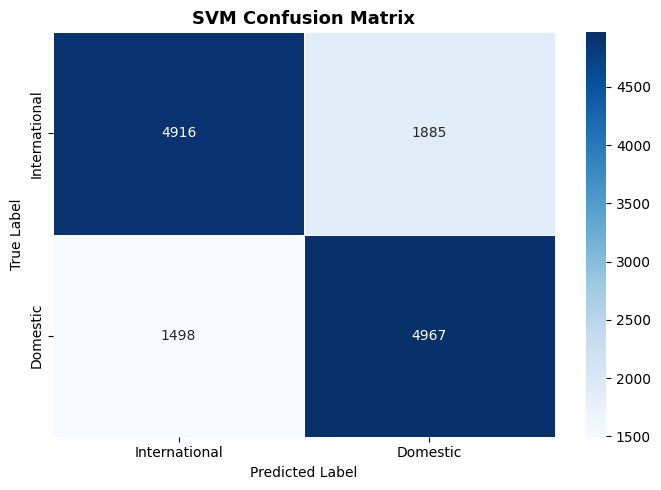

In [9]:
# ── Plot confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['International', 'Domestic'],
            yticklabels=['International', 'Domestic'],
            linewidths=0.5, ax=ax)
ax.set_title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretation of Results**

The confusion matrix shows the breakdown of correct and incorrect predictions
across both classes. The model correctly identified 4,924 international routes
and 4,905 domestic routes, which form the diagonal of the matrix and represent
the majority of predictions. On the other hand, 1,910 international routes were
incorrectly predicted as domestic, and 1,537 domestic routes were incorrectly
predicted as international. The misclassification is fairly balanced between both classes, which is consistent with the similar precision and recall scores seen in the classification report.

## 4.2 SVM Decision Boundary Visualization

Since SVM operates across 12 features, the decision boundary cannot be plotted
directly. To visualize it, we use Principal Component Analysis (PCA) to compress the 12 features down to 2 dimensions, then refit the SVM on these 2 components and plot the resulting boundary. It is important to note that
this plot serves as a visual approximation rather than an exact representation
of the full model.

Variance explained by PC1     : 25.95%
Variance explained by PC2     : 17.20%
Total variance explained      : 43.16%


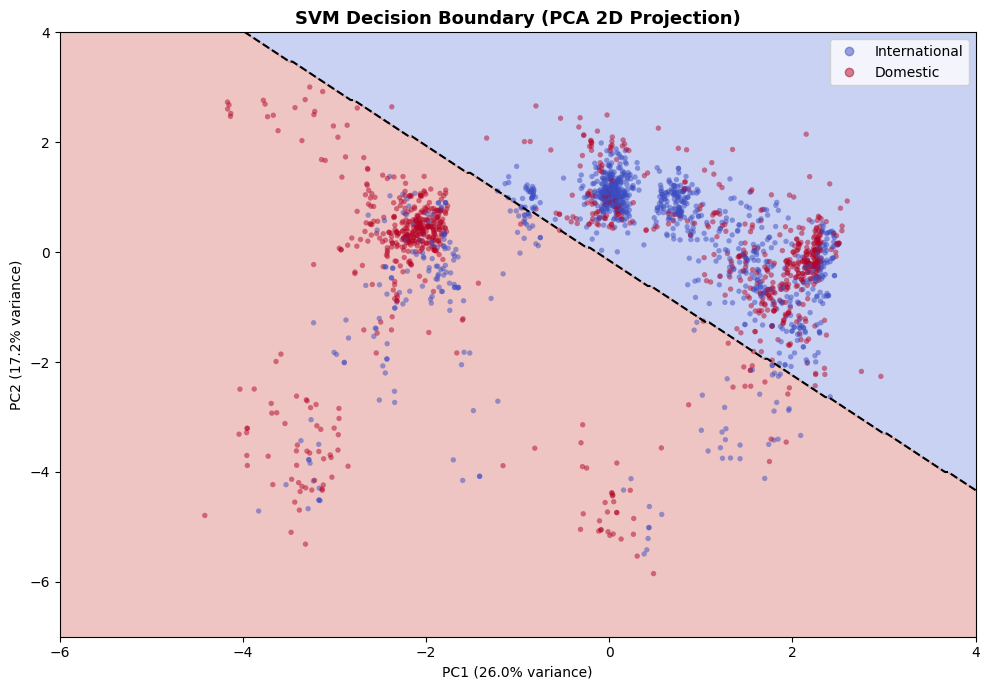

In [10]:
# ── Reduce to 2D using PCA ────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1     : {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2     : {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained      : {pca.explained_variance_ratio_.sum():.2%}")

# ── Refit SVM on 2 PCA components ────────────────────────────────────────
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
svm_pca = LinearSVC(max_iter=2000, random_state=42)
svm_pca.fit(X_train_pca, y_train_pca)

# ── Create decision boundary mesh ─────────────────────────────────────────
xx, yy = np.meshgrid(np.linspace(-6, 4, 300), np.linspace(-7, 4, 300))
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# ── Sample 2000 points for scatter (avoid overplotting) ───────────────────
np.random.seed(42)
idx = np.random.choice(len(X_pca), 2000, replace=False)
X_sample = X_pca[idx]
y_sample = y.values[idx]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.contour(xx, yy, Z, levels=[0.5], colors='black',
           linewidths=1.5, linestyles='--')
scatter = ax.scatter(X_sample[:, 0], X_sample[:, 1],
                     c=y_sample, cmap='coolwarm',
                     alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('SVM Decision Boundary (PCA 2D Projection)', fontsize=13, fontweight='bold')
ax.legend(handles=scatter.legend_elements()[0],
          labels=['International', 'Domestic'], loc='upper right')
plt.tight_layout()
plt.show()

**Interpretation of Results**

PC1 captures 25.9% of the variance and PC2 captures 17.2%, giving a combined
explanation of 43.14% of the total variance in the data. The dashed black line
represents the decision boundary — the hyperplane that the SVM learned to
separate domestic from international routes. Points on the red side are
predicted as domestic, while points on the blue side are predicted as
international.

The considerable overlap between the two classes in the plot is expected
for two reasons. First, compressing 12 dimensions down to 2 loses a significant
amount of information, so routes that are separable in the full feature space
may appear mixed here. Second, some domestic and international routes genuinely
share similar geographic and infrastructure characteristics, which is reflected
in the 26% misclassification rate of the full model.

## Conclusion

Applying SVM to classify domestic and international routes taught us that
geographic and infrastructure features alone can predict route type with
reasonable accuracy. A 74% accuracy suggests that the physical characteristics of a route — how far it travels, where it originates, and what type of airports
it connects — already carry enough signal to distinguish domestic from
international travel in most cases.

What was perhaps most interesting is how balanced the model performed across
both classes. The similar precision and recall scores suggest that
domestic and international routes are equally challenging to distinguish from
a purely geographic perspective. The 26% misclassification rate also raises an interesting question — these are routes that look international but are domestic, or vice versa.

# 5. Unsupervised Learning

## 5.1 K-Means Clustering

The Question: Can airports be grouped into meaningful categories based purely on their geographic and operational characteristics, without using any predefined labels?

Apply K-Means clustering to group airports based on their
operational characteristics. Rather than working at the route level, we aggregate the data at the airport level, capturing each airport's geographic position, elevation, number of routes, average route distance, number of unique destinations, and number of continents served. The goal is to discover whether airports naturally group into meaningful categories based on these features, without using any predefined labels.

In [11]:
# ── Aggregate data at airport level ──────────────────────────────────────
airport_df = master_df.groupby('src_iata').agg(
    lat=('src_lat', 'first'),
    lon=('src_lon', 'first'),
    elevation=('src_elevation', 'first'),
    route_count=('dst_iata', 'count'),
    avg_distance=('distance_km', 'mean'),
    unique_destinations=('dst_iata', 'nunique'),
    unique_continents=('dst_continent', 'nunique')
).reset_index()

print(f"Total airports: {len(airport_df)}")
print("\nAirport feature summary:")
print(airport_df[['route_count','avg_distance','unique_destinations','unique_continents']].describe().round(2))

Total airports: 3375

Airport feature summary:
       route_count  avg_distance  unique_destinations  unique_continents
count      3375.00       3375.00              3375.00            3375.00
mean         19.67        784.21                10.89               1.32
std          53.18        726.79                23.95               0.75
min           1.00          3.00                 1.00               1.00
25%           2.00        265.95                 1.00               1.00
50%           4.00        569.75                 3.00               1.00
75%          11.00       1069.64                 8.00               1.00
max         915.00       5581.00               236.00               6.00


**Interpretation of Results**

The dataset contains 3,375 unique source airports. The route count per airport
ranges widely, from 1 to 236 routes, with a mean of around 11 unique destinations per airport. Most airports serve only 1 continent, while a small number reach up to 6, indicating that the majority of airports operate regionally. This spread across features suggests that airports are likely to form distinct groups based on their operational scale.

To determine the best value of k, we use two methods. The elbow method plots
inertia against k, where inertia measures how tightly data points are grouped
within each cluster — a lower value is better. The silhouette score measures
how well each point fits its own cluster compared to neighboring clusters,
where a higher score indicates better-defined clusters.

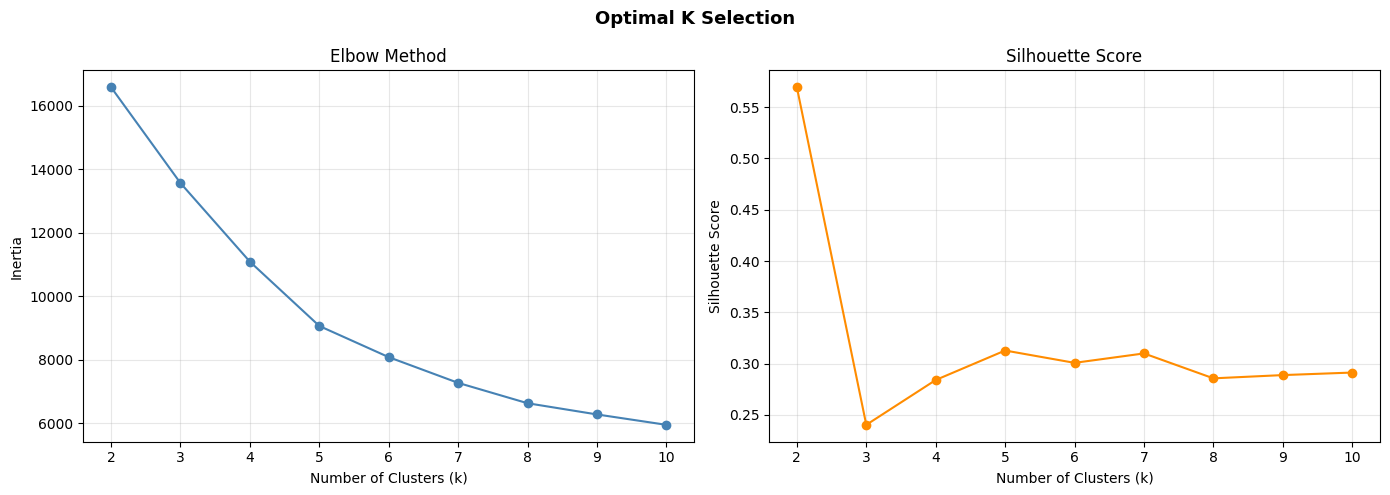

In [12]:
# ── Scale features ────────────────────────────────────────────────────────
features_cluster = ['lat', 'lon', 'elevation', 'route_count',
                    'avg_distance', 'unique_destinations', 'unique_continents']

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(airport_df[features_cluster])

# ── Elbow and silhouette scores for k=2 to 10 ────────────────────────────
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labels))

# ── Plot elbow and silhouette ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The elbow plot does not show a sharp bend, meaning there is no single
dominant k that stands out. The inertia decreases gradually and begins
to flatten from k=5 onwards. The silhouette score is highest at k=2
(0.57), but drops sharply at k=3 before stabilizing around 0.28–0.31
from k=4 onward with no meaningful improvement. While k=2 produces the
most statistically separated clusters, it is too broad to be analytically
useful. We therefore select k=4 as it sits at the point where inertia
starts to level off and produces cluster groupings that are meaningful
and interpretable in the context of airport operations.

Fit the K-Means model using k=4 and assign each airport to its
corresponding cluster. The clustering is based on a combination of geographic
features — latitude, longitude, and elevation — alongside operational features
such as route count, average distance, unique destinations, and continents served.

In [13]:
# ── Fit K-Means with k=4 ─────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
airport_df['cluster'] = kmeans.fit_predict(X_km)

# ── Full cluster profile including geographic features ────────────────────
cluster_profile = airport_df.groupby('cluster')[
    ['lat', 'lon', 'elevation', 'route_count',
     'avg_distance', 'unique_destinations', 'unique_continents']
].mean().round(2)

print("Cluster profiles:")
print(cluster_profile)
print("\nAirports per cluster:")
print(airport_df['cluster'].value_counts().sort_index())

Cluster profiles:
           lat    lon  elevation  route_count  avg_distance  \
cluster                                                       
0        42.35 -69.58     198.10         5.93        474.83   
1         4.86  72.27     453.37         6.18        590.93   
2        36.37   3.93     210.22       274.58       2524.40   
3        31.05  20.87     199.57        46.71       1828.21   

         unique_destinations  unique_continents  
cluster                                          
0                       4.18               1.04  
1                       3.93               1.04  
2                     125.17               4.14  
3                      26.81               2.28  

Airports per cluster:
cluster
0    1487
1    1273
2      92
3     523
Name: count, dtype: int64


**Interpretation of Results**

The cluster profiles reveal four distinct groups of airports:

- Cluster 2 (92 airports): The smallest group but the most operationally
  dominant, averaging 275 routes, 125 unique destinations, and serving
  over 4 continents. These are major **global hubs**.
- Cluster 3 (523 airports): Mid-scale airports averaging 47 routes and
  27 unique destinations across around 2 continents. These function as
  **regional hubs**.
- Clusters 0 and 1 (1487 and 1273 airports respectively): The largest group, averaging fewer than 7 routes and serving mostly 1 continent which makes them operationally very similar. These are **local airports** with limited connectivity.

The reason Clusters 0 and 1 appear as separate groups despite their similar
operational profiles is that geographic coordinates — latitude and longitude —
are included as clustering features. Cluster 0 has an average latitude of 42 and longitude of -70, placing it in North America, while Cluster 1 has an average latitude of 5 and longitude of 72, placing it in Asia.

## 5.2 Visualizing the Clusters

To better understand what each cluster represents, we plot the results in two
ways. The first plot maps each airport geographically using latitude and longitude, allowing us to see how the clusters distribute across the world. The second plot compares route count against average distance, showing how the clusters differ in terms of operational scale.

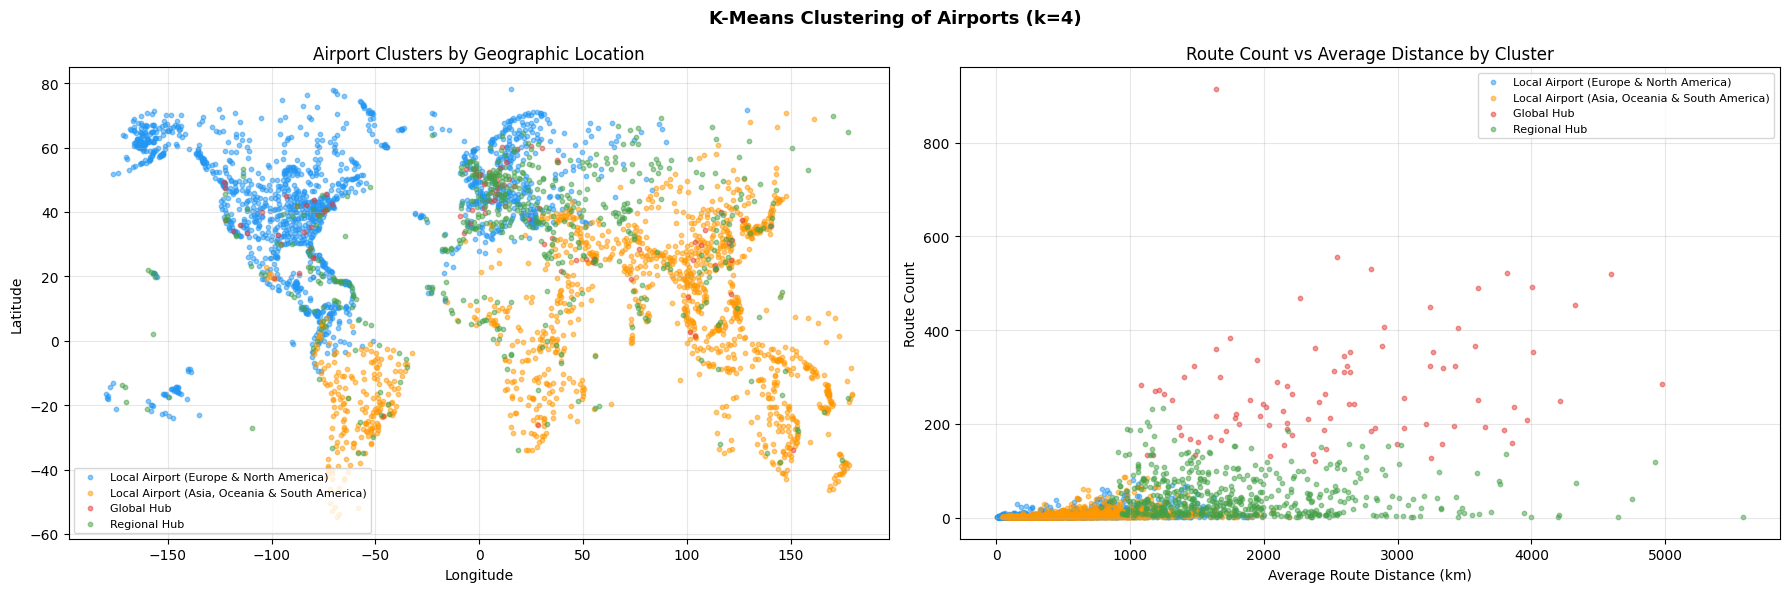

In [14]:
# ── Plot clusters on geographic map ──────────────────────────────────────
cluster_colors = {0: '#2196F3', 1: '#FF9800', 2: '#E53935', 3: '#43A047'}
cluster_labels = {
    0: 'Local Airport (Europe & North America)',
    1: 'Local Airport (Asia, Oceania & South America)',
    2: 'Global Hub',
    3: 'Regional Hub'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('K-Means Clustering of Airports (k=4)', fontsize=13, fontweight='bold')

# Panel 1 — Geographic scatter
ax1 = axes[0]
for cluster_id, group in airport_df.groupby('cluster'):
    ax1.scatter(group['lon'], group['lat'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax1.set_title('Airport Clusters by Geographic Location')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2 — Route count vs avg distance
ax2 = axes[1]
for cluster_id, group in airport_df.groupby('cluster'):
    ax2.scatter(group['avg_distance'], group['route_count'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax2.set_title('Route Count vs Average Distance by Cluster')
ax2.set_xlabel('Average Route Distance (km)')
ax2.set_ylabel('Route Count')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The geographic plot reveals that aviation infrastructure is not evenly
distributed across the world. **Global hubs** are tightly concentrated in
Europe, North America, and East Asia — regions with the highest economic
activity and travel demand. **Regional hubs** fill in the gaps across Africa,
the Middle East, and Southeast Asia. **Local airports**, despite being the most
numerous, are scattered across all continents with no dominant concentration,
reflecting that basic air connectivity exists widely but at a limited scale.

The route count vs average distance plot reinforces this hierarchy. Global
hubs stand out clearly in the upper right, combining high route counts with
long average distances. Regional hubs sit in the middle ground, while both
local airport clusters concentrate in the lower left with few routes and
short distances, confirming their limited operational scope.

## 5.3 Comparing Clusters with Actual Airport Types

To assess whether the K-Means clusters align with real-world airport
classifications, we plot the airports using their actual labeled types
from the dataset and compare them side by side with the cluster results.

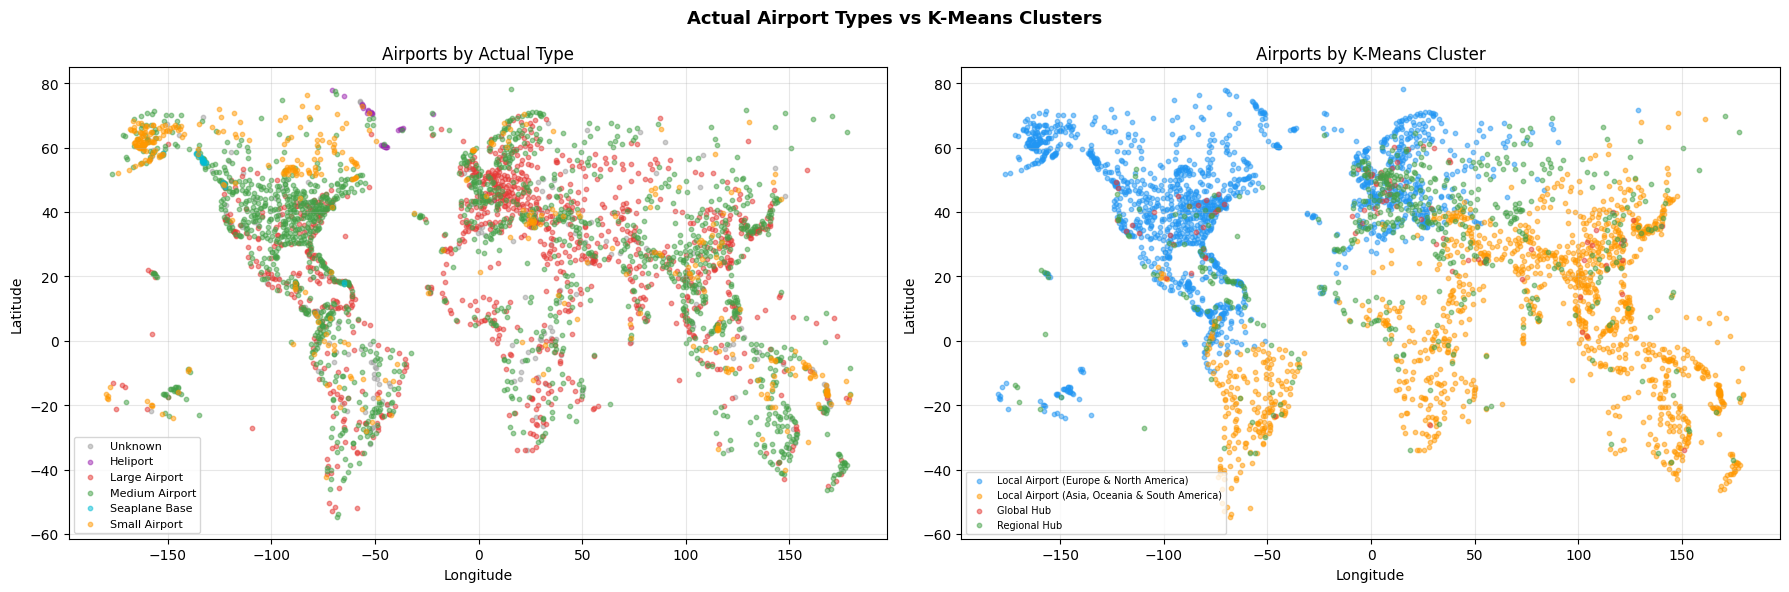

In [15]:
# ── Plot airports by actual labeled type ─────────────────────────────────
type_colors = {
    'large_airport'  : '#E53935',
    'medium_airport' : '#43A047',
    'small_airport'  : '#FF9800',
    'heliport'       : '#9C27B0',
    'seaplane_base'  : '#00BCD4',
    'Unknown'        : '#9E9E9E'
}

# Keep only airports in our clustered dataset
airport_plot = airport_df.copy()
airport_plot = airport_plot.merge(
    master_df[['src_iata', 'src_airport_type']].drop_duplicates(),
    on='src_iata', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Actual Airport Types vs K-Means Clusters',
             fontsize=13, fontweight='bold')

# Panel 1 — Actual airport types
ax1 = axes[0]
for atype, group in airport_plot.groupby('src_airport_type'):
    ax1.scatter(group['lon'], group['lat'],
                c=type_colors.get(atype, '#9E9E9E'),
                label=atype.replace('_', ' ').title(),
                alpha=0.5, s=10)
ax1.set_title('Airports by Actual Type')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2 — K-Means clusters (for direct comparison)
ax2 = axes[1]
for cluster_id, group in airport_df.groupby('cluster'):
    ax2.scatter(group['lon'], group['lat'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax2.set_title('Airports by K-Means Cluster')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend(loc='lower left', fontsize=7)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The comparison reveals an interesting finding. While global hubs identified
by K-Means do align with large airports in the labeled data, many large
airports are not classified as global hubs. This is visible in the left plot
where large airports (red) are spread widely across all continents, yet in
the right plot, many of those same locations appear as local or regional
clusters rather than global hubs. This suggests that being categorized as
a large airport does not automatically translate to high route capacity or
global connectivity.

This is an important distinction — the original dataset classifies airports
by physical infrastructure size, not by the volume of routes they operate.
A large airport in a smaller or less connected market may still serve a
limited number of routes, while a medium airport in a highly connected hub
city could outperform it in terms of connectivity. The K-Means clusters
capture this operational reality more accurately than the size label alone.

## Conclusion

In this section, we applied K-Means clustering to group airports resulting in four distinct groups — Global Hubs, Regional Hubs, and two Local Airport clusters separated by geographic location. Applying K-Means clustering to airports taught us that the global aviation network is far more unequal than it might appear. Without being given any labels, the algorithm naturally arrived at groupings that reflect real-world airport roles, and the fact that these clusters align with actual airport types confirms that operational characteristics alone are strong enough to define an airport's place in the global network. Most strikingly, just 92 airports drive 38.1% of all routes in the dataset.

The analysis also challenged the assumption that airport size determines
capacity. Many airports labeled as large did not make it into the global
hub cluster, suggesting that physical infrastructure and operational output
do not always go hand in hand. This is something that predefined labels alone would not have surfaced, and it demonstrates the value of unsupervised learning in uncovering structure that goes beyond what is explicitly recorded in the data.